# Discriminando Fenotipos de Respuesta a Fármacos Oncológicos a partir de Biomarcadores Farmacodinámicos con PROC HPCANDISC


## Resumen Ejecutivo

En un ensayo oncológico de Fase II, los pacientes caen en fenotipos de respuesta distintos (no respondedor, parcial, completo) que rara vez son separables en un solo biomarcador. Este notebook usa análisis discriminante canónico de alto rendimiento (PROC HPCANDISC) para encontrar las combinaciones lineales de cinco biomarcadores farmacodinámicos que separan al máximo los tres grupos de respuesta, cuantifica qué tan fuertemente discrimina cada eje, y puntúa a cada paciente en el espacio canónico para visualización y triaje posteriores.


## Fuentes de Datos

**Conjunto de datos sintético: `work.pkpd`** — 99 pacientes simulados de un ensayo oncológico de Fase II, una fila por paciente, generados en línea con `call streaminit(20260531)` y `rand("Normal", ...)`. Los pacientes se asignan en orden round-robin a uno de tres fenotipos de respuesta a fármacos (33 por grupo), y se extraen cinco biomarcadores farmacodinámicos a partir de medias específicas de grupo más ruido gaussiano, de modo que los grupos se superponen de forma realista en lugar de separarse perfectamente.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `PatientID` | Num | Identificador único de paciente (1–99) |
| `ResponseGroup` | Char | Fenotipo de respuesta: `NonResponder`, `Partial`, `Complete` (la variable CLASS) |
| `TumorShrinkage` | Num | Reducción tumoral RECIST (% de reducción en el diámetro de la lesión objetivo) |
| `IL6_pgml` | Num | Interleucina-6 sérica (pg/mL); marcador inflamatorio, más alto en no respondedores |
| `ctDNA_copies` | Num | ADN tumoral circulante (copias/mL); carga de enfermedad residual |
| `DrugAUC` | Num | Exposición al fármaco, AUC0–24 plasmática (ng·h/mL) |
| `QoLScore` | Num | Puntuación de calidad de vida reportada por el paciente (0–100) |


# Discriminando Fenotipos de Respuesta a Fármacos Oncológicos con Análisis Discriminante Canónico

En ensayos oncológicos de fase temprana, los pacientes se clasifican en **fenotipos** de respuesta — no respondedores, respondedores parciales y respondedores completos — pero la biología que impulsa esas etiquetas es multivariada. Ningún biomarcador aislado separa limpiamente los grupos: un no respondedor puede compartir la reducción tumoral con un respondedor parcial pero diferir en marcadores inflamatorios y de residuo molecular.

**El análisis discriminante canónico** encuentra las combinaciones lineales de los biomarcadores medidos (las *variables canónicas*) que maximizan la separación entre los grupos conocidos. Con *k* grupos y *p* biomarcadores, produce hasta mín(*k*−1, *p*) ejes canónicos, ordenados por cuánta separación entre grupos captura cada uno.

Usamos `PROC HPCANDISC`, la contraparte multihilo de alto rendimiento de `PROC CANDISC`, sobre un panel de cinco biomarcadores farmacodinámicos medidos en 99 pacientes del ensayo.


## Paso 1 — Generar una cohorte sintética de ensayo realista

Simulamos 99 pacientes divididos equitativamente (33 cada uno) entre los tres fenotipos de respuesta. Para cada fenotipo fijamos medias de grupo plausibles para los cinco biomarcadores, luego agregamos ruido gaussiano con `rand("Normal", ...)` de modo que los grupos se superpongan — exactamente la situación de separación parcial donde el análisis discriminante canónico demuestra su valor. `call streaminit` fija la semilla para reproducibilidad. Los arreglos `_temporary_` contienen las medias por grupo de modo que la simulación se lee como una pequeña matriz de diseño.


In [1]:
DATOS work.pkpd;
  LLAMAR streaminit(20260531);
  LONGITUD ResponseGroup $13;

  /* Medias por grupo: indice 1=NonResponder, 2=Partial, 3=Complete */
  ARREGLO m_tumor[3] _temporary_ (12   35   62);   /* % reduccion tumoral      */
  ARREGLO m_il6[3]   _temporary_ (48   30   18);   /* IL-6 (pg/mL)           */
  ARREGLO m_ctdna[3] _temporary_ (240  120  45);   /* ADNct (copias/mL)      */
  ARREGLO m_auc[3]   _temporary_ (820  980  1150);  /* AUC del farmaco (ng*h/mL)    */
  ARREGLO m_qol[3]   _temporary_ (45   62   78);    /* puntuacion de calidad de vida */

  HACER PatientID = 1 HASTA 99;
    g = 1 + mod(PatientID - 1, 3);
    SELECCIONAR (g);
      CUANDO (1) ResponseGroup = "NonResponder";
      CUANDO (2) ResponseGroup = "Partial";
      CUANDO (3) ResponseGroup = "Complete";
    END;

    TumorShrinkage = m_tumor[g] + rand("Normal", 0, 7);
    IL6_pgml       = m_il6[g]   + rand("Normal", 0, 6);
    ctDNA_copies   = m_ctdna[g] + rand("Normal", 0, 30);
    DrugAUC        = m_auc[g]   + rand("Normal", 0, 60);
    QoLScore       = m_qol[g]   + rand("Normal", 0, 8);
    SALIDA;
  END;

  ELIMINAR g;
  ETIQUETA ResponseGroup  = "Grupo de Respuesta"
        TumorShrinkage = "Reduccion Tumoral (%)"
        IL6_pgml       = "IL-6 Serica (pg/mL)"
        ctDNA_copies   = "ADNct (copias/mL)"
        DrugAUC        = "AUC del Farmaco (ng*h/mL)"
        QoLScore       = "Puntuacion de Calidad de Vida";
EJECUTAR;



NOTE: DATA work.pkpd


NOTE: Wrote work.pkpd (99 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Paso 2 — Inspeccionar la estructura de grupo cruda

Antes de ejecutar el análisis discriminante, resumimos los biomarcadores dentro de cada grupo de respuesta con `PROC MEANS`. Esto confirma que la separación simulada es realista — las medias de grupo difieren pero las desviaciones estándar son lo suficientemente grandes como para que las distribuciones se superpongan en cada marcador individual.


In [2]:
PROCEDIMIENTO MEDIAS DATOS=work.pkpd n mean std MIN MAX maxdec=1;
  CLASE ResponseGroup;
  VAR TumorShrinkage IL6_pgml ctDNA_copies DrugAUC QoLScore;
EJECUTAR;


                                                  The MEANS Procedure

                                Analysis Variable : TumorShrinkage Reduccion Tumoral (%)

        Grupo de Respuesta          N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------
        Complete                       33           60.0            7.8           45.7           72.8
        NonResponder                   33           12.3            6.6           -3.6           24.3
        Partial                        33           35.4            7.0           22.6           47.5
        ---------------------------------------------------------------------------------------------

                                    Analysis Variable : IL6_pgml IL-6 Serica (pg/mL)

        Grupo de Respuesta          N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Paso 3 — Análisis discriminante canónico

Este es el análisis central. Le pedimos a `PROC HPCANDISC` que discrimine `ResponseGroup` usando los cinco biomarcadores y solicitamos los diagnósticos que importan para la interpretación:

- **`SIMPLE`** — estadísticas descriptivas de la muestra total y dentro de cada clase.
- **`ANOVA`** — pruebas F univariadas de igualdad de medias de clase, una por biomarcador, mostrando qué marcadores llevan señal por sí solos.
- **`DISTANCE`** — distancias de Mahalanobis al cuadrado entre las medias de grupo con pruebas F, cuantificando qué tan separados están los fenotipos en el espacio multivariado.
- **`STDMEAN`** — medias de clase estandarizadas en las variables canónicas, para que los ejes puedan leerse en una escala común.

Con tres grupos podemos extraer como máximo dos ejes canónicos, así que fijamos `NCAN=2`. El procedimiento también reporta las correlaciones canónicas y las pruebas multivariadas (Lambda de Wilks, Traza de Pillai) para la separación general de grupos.



Simple Statistics

Total: N = 99
Variable                                   N            Sum           Mean       Variance        Std Dev
Reduccion Tumoral (%)                     99    3552.441616      35.883249     433.857790      20.829253
IL-6 Serica (pg/mL)                       99    3195.981365      32.282640     182.490266      13.508896
ADNct (copias/mL)                         99   13341.881640     134.766481    7590.136739      87.121391
AUC del Farmaco (ng*h/mL)                 99   97121.081467     981.021025   21582.069586     146.908371
Puntuacion de Calidad de Vida             99    6077.845082      61.392375     217.214485      14.738198

Complete: N = 33
Variable                                   N            Sum           Mean       Variance        Std Dev
Reduccion Tumoral (%)                     33    1978.954667      59.968323      60.636225       7.786927
IL-6 Serica (pg/mL)                       33     598.809923      18.145755      29.571393       5.437959
ADN


NOTE: PROC HPCANDISC
NOTE: PROC CANDISC data=work.pkpd ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 99
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   Complete: 33
NOTE:   NonResponder: 33
NOTE:   Partial: 33
NOTE: Simple Statistics displayed (SIMPLE option).
NOTE: Canonical Correlations:
NOTE:   Can1: 0.981638
NOTE:   Can2: 0.436484
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       26.482174    0.981638            0.963613
NOTE:   Can2        0.235358    0.436484            0.190518
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.029455     88.81      10   184.0   0.0000
NOTE:   Pillai's Trace        1.154131     25.11      10   184.0   0.0000
NOTE:   Ho

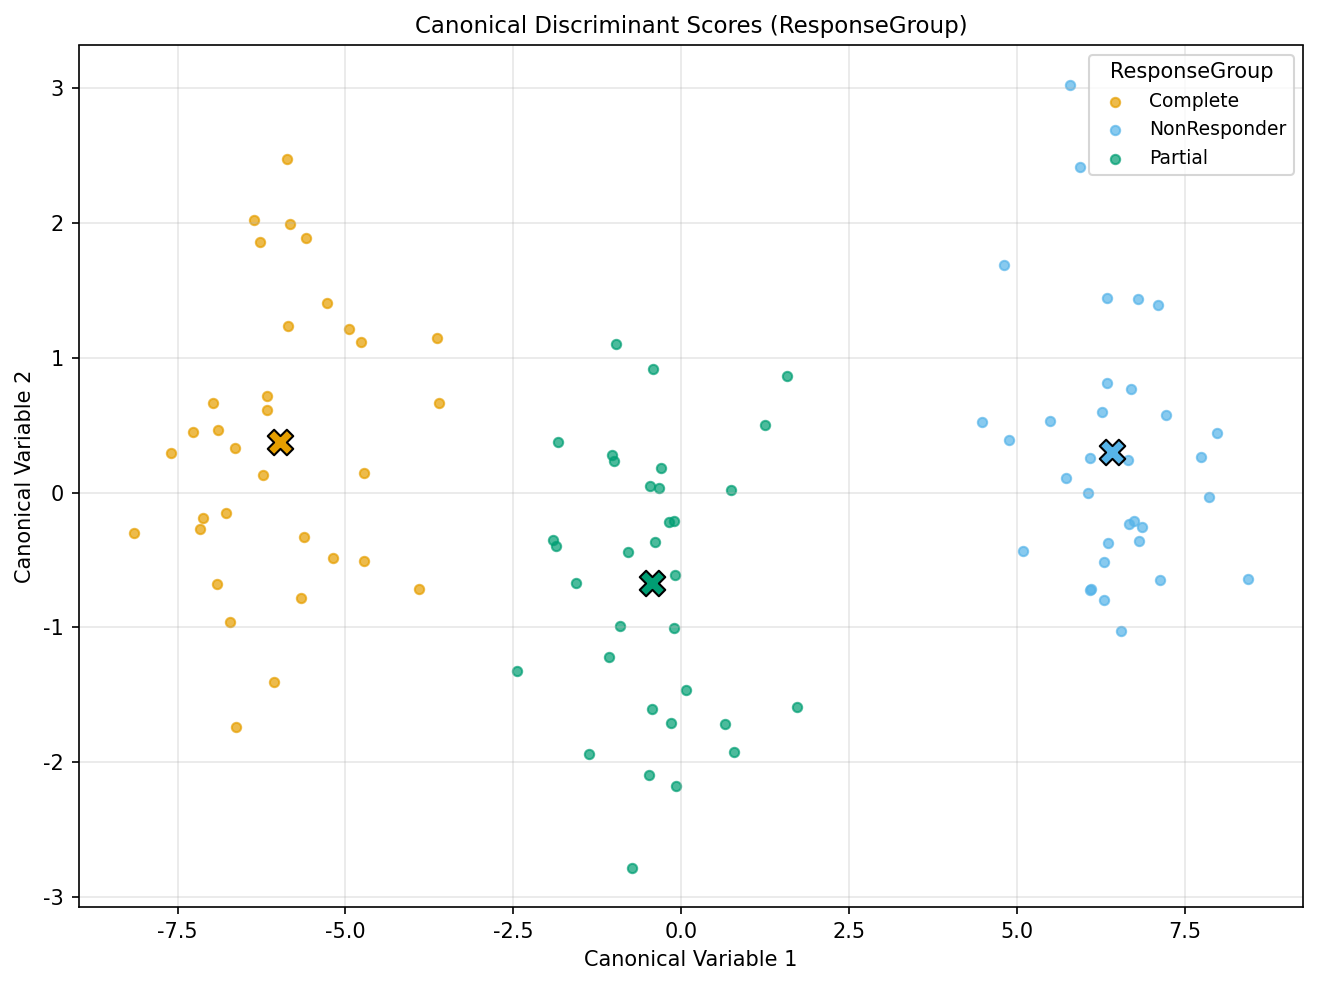

In [3]:
PROCEDIMIENTO hpcandisc DATOS=work.pkpd ncan=2
               simple ANOVA distance stdmean;
  CLASE ResponseGroup;
  VAR TumorShrinkage IL6_pgml ctDNA_copies DrugAUC QoLScore;
EJECUTAR;


## Paso 4 — Puntuar pacientes en los ejes canónicos

El conjunto de datos `OUT=` adjunta las puntuaciones canónicas de cada paciente (`Can1`, `Can2`) a los datos. Renombramos el prefijo canónico con `PREFIX=CanAxis` para mayor claridad y llevamos `PatientID` y `ResponseGroup` mediante una sentencia `ID` de modo que el conjunto de datos puntuado sea inmediatamente utilizable para un gráfico de separación 2-D o para marcar pacientes cuya posición canónica no coincide con su fenotipo asignado.



PatientID  ResponseGroup   CANAXIS1   CANAXIS2
---------  -------------  ---------  ---------
        1  NonResponder    6.053775  -0.003541
        2  Partial         0.790931  -1.925165
        3  Complete        -6.22034   0.127655
        4  NonResponder    6.659439   -0.23629
        5  Partial        -1.836782   0.377423
        6  Complete       -5.279015   1.406605
        7  NonResponder    7.091362   1.394368
        8  Partial        -0.328456   0.037976
        9  Complete       -6.724992  -0.959181

... 90 more observations (showing 9 of 99)




NOTE: PROC HPCANDISC
NOTE: PROC CANDISC data=work.pkpd ncan=Some(2) prefix=CanAxis

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 99
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   Complete: 33
NOTE:   NonResponder: 33
NOTE:   Partial: 33
NOTE: Canonical Correlations:
NOTE:   Can1: 0.981638
NOTE:   Can2: 0.436484
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       26.482174    0.981638            0.963613
NOTE:   Can2        0.235358    0.436484            0.190518
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.029455     88.81      10   184.0   0.0000
NOTE:   Pillai's Trace        1.154131     25.11      10   184.0   0.0000
NOTE:   Hotelling-Lawley     26.717532    327.07      10 

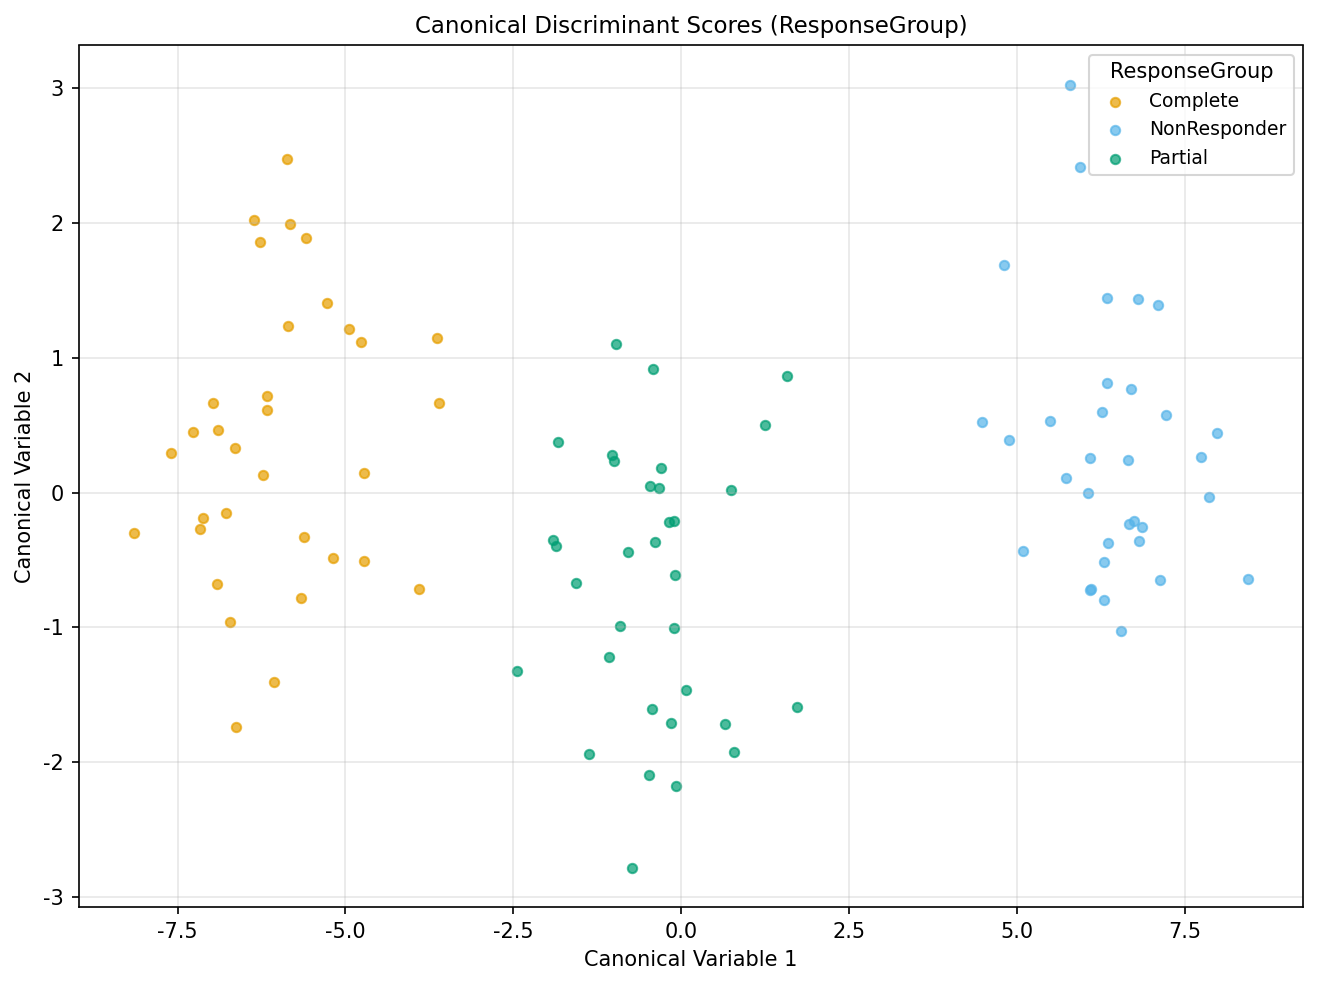

In [4]:
PROCEDIMIENTO hpcandisc DATOS=work.pkpd out=work.canscores
               ncan=2 PREFIX=CanAxis short;
  CLASE ResponseGroup;
  VAR TumorShrinkage IL6_pgml ctDNA_copies DrugAUC QoLScore;
  id PatientID ResponseGroup;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.canscores(obs=9) noobs;
  VAR PatientID ResponseGroup CanAxis1 CanAxis2;
EJECUTAR;


## Paso 5 — Posición canónica media por fenotipo

Promediar las puntuaciones canónicas dentro de cada grupo de respuesta da los **centroides** de grupo en el espacio canónico. La dispersión de estos centroides a lo largo de `CanAxis1` versus `CanAxis2` muestra, concretamente, qué eje realiza el trabajo de separación.


In [5]:
PROCEDIMIENTO MEDIAS DATOS=work.canscores mean maxdec=3;
  CLASE ResponseGroup;
  VAR CanAxis1 CanAxis2;
EJECUTAR;


                                                  The MEANS Procedure

                                             Analysis Variable : CANAXIS1

                                                                 N
                                         Grupo de Respuesta    Obs        Mean
                                         -------------------------------------
                                         Complete               33      -5.979
                                         NonResponder           33       6.411
                                         Partial                33      -0.431
                                         -------------------------------------

                                             Analysis Variable : CANAXIS2

                                                                 N
                                         Grupo de Respuesta    Obs        Mean
                                         -------------------------------------
            


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Paso 6 — Persistir los coeficientes del modelo canónico

El conjunto de datos `OUTSTAT=` es una tabla `TYPE=CORR` que contiene las medias de clase, las correlaciones canónicas, la estructura canónica (correlaciones entre cada biomarcador y cada eje canónico), y los coeficientes canónicos crudos y estandarizados. Guardarlo nos permite aplicar la misma transformación canónica a pacientes futuros sin reajustar, y nos permite leer qué biomarcadores cargan más pesadamente en cada eje.



  _TYPE_          _NAME_  TUMORSHRINKAGE  IL6_PGML  CTDNA_COPIES  DRUGAUC  QOLSCORE       CAN1      CAN2
--------  --------------  --------------  --------  ------------  -------  --------  ---------  --------
CANCORR                                .         .             .        .         .   0.981638  0.436484
STRUCTUR  TumorShrinkage               .         .             .        .         .  -0.534553  0.435375
STRUCTUR  IL6_pgml                     .         .             .        .         .   0.431265  0.151311
STRUCTUR  ctDNA_copies                 .         .             .        .         .   0.539255  0.711061
STRUCTUR  DrugAUC                      .         .             .        .         .  -0.431336   0.37645
STRUCTUR  QoLScore                     .         .             .        .         .  -0.363398   0.11153




NOTE: PROC HPCANDISC
NOTE: PROC CANDISC data=work.pkpd ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: ODS plot written: candisc_scores.spec.json
NOTE: PROC CANDISC: 99 observations, 5 variables
NOTE: PROC PRINT data=work.canstat

NOTE: PROC PRINT completed: 6 observations printed, 9 variables


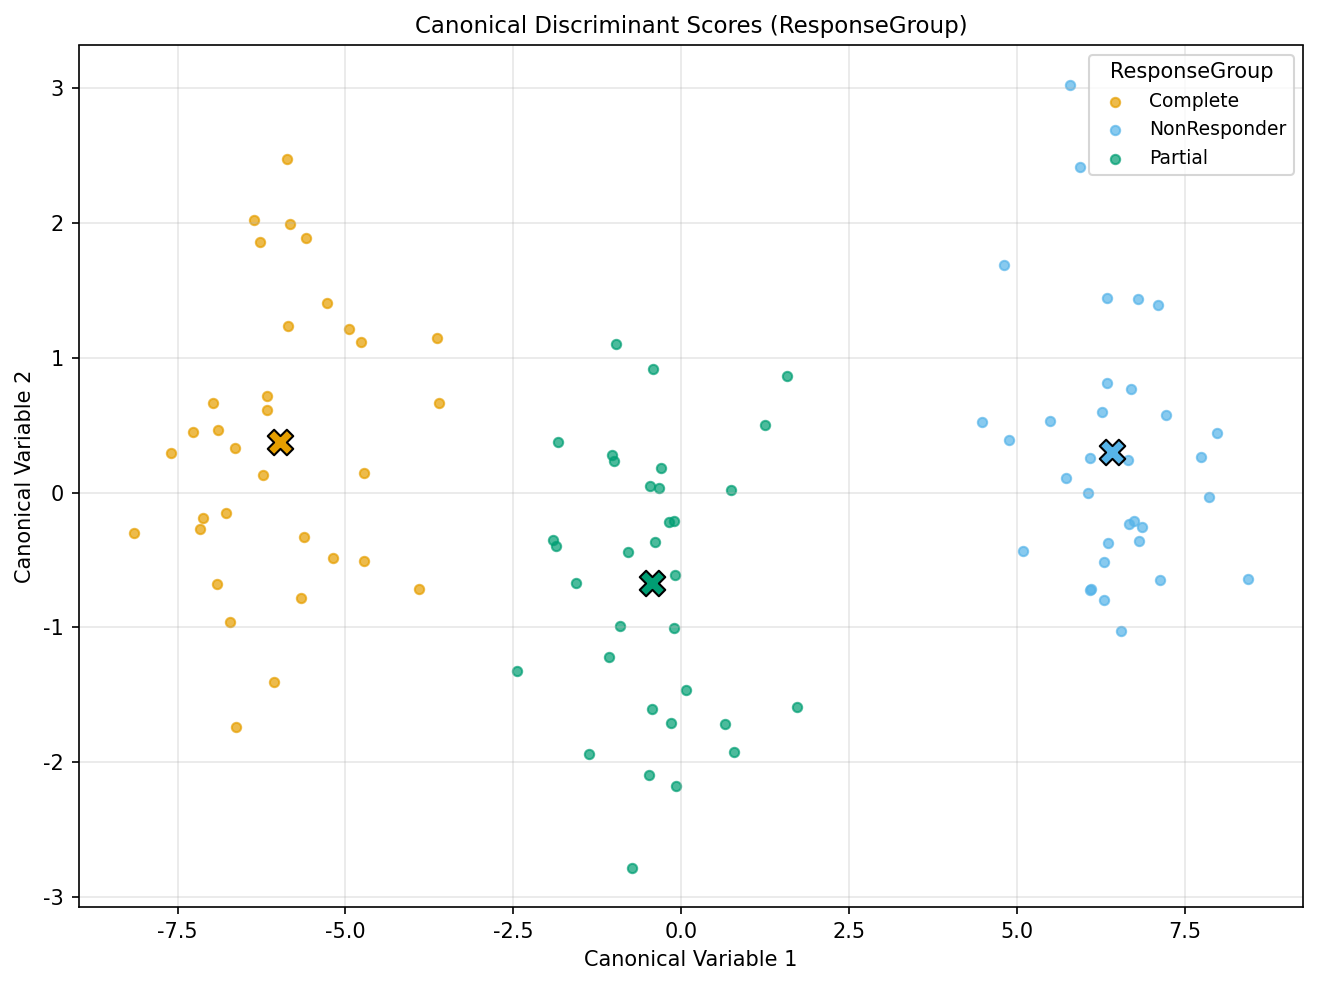

In [6]:
PROCEDIMIENTO hpcandisc DATOS=work.pkpd OUTSTAT=work.canstat
               ncan=2 NOPRINT;
  CLASE ResponseGroup;
  VAR TumorShrinkage IL6_pgml ctDNA_copies DrugAUC QoLScore;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.canstat noobs;
  DONDE _TYPE_ IN ("STRUCTUR", "CANCORR");
EJECUTAR;


## Interpretando los resultados

**Separación general.** Las pruebas multivariadas (Lambda de Wilks = 0.0295, Traza de Pillai = 1.154, Hotelling-Lawley = 26.72) son todas altamente significativas (p < 0.0001), confirmando que los tres fenotipos de respuesta son fuertemente distinguibles en el panel de cinco biomarcadores tomado en conjunto.

**Ejes canónicos.** La primera variable canónica lleva casi todo el poder discriminante — su correlación canónica al cuadrado es 0.964 (correlación canónica 0.982), así que explica la abrumadora mayoría de la variación entre grupos. El segundo eje es más débil (correlación canónica al cuadrado 0.191) pero aún significativo: la prueba secuencial de que la correlación restante es cero se rechaza en p = 0.0005. En la práctica, una sola puntuación canónica (`CanAxis1`) ordena los fenotipos a lo largo de un gradiente monotónico limpio — los centroides de grupo caen en -5.98 (Complete), -0.43 (Partial), y +6.41 (NonResponder), así que `CanAxis1` separa limpiamente a los respondedores completos de los no respondedores con los respondedores parciales en medio.

**Qué biomarcadores impulsan la separación.** Las pruebas F `ANOVA` univariadas muestran que cada biomarcador difiere entre grupos (todos F > 168, p < 0.0001), pero la **estructura canónica** (de la tabla `OUTSTAT=`) revela la historia multivariada: en `CanAxis1` la carga de ADNct (0.539) y la reducción tumoral (-0.535) cargan más pesadamente — el gradiente de respuesta dominante — mientras que el AUC del fármaco (-0.431), IL-6 (0.431), y la calidad de vida (-0.363) contribuyen con señal progresivamente más débil. Las distancias de Mahalanobis al cuadrado de la opción `DISTANCE` cuantifican las brechas: los respondedores completos y no respondedores están más alejados entre sí (153.5), con los respondedores parciales en posición intermedia (31.9 a Complete, 47.8 a NonResponder), coincidiendo con la intuición clínica.

**Uso práctico.** El conjunto de datos puntuado `work.canscores` coloca a cada paciente en un mapa de separación bidimensional. Los pacientes cuya posición canónica cae lejos del centroide de su fenotipo asignado son candidatos para revisión de adjudicación, y los coeficientes guardados de `OUTSTAT=` permiten al equipo del ensayo proyectar a los pacientes recién inscritos sobre los mismos ejes para monitoreo de respuesta en tiempo real.
